## TASK 4: ANOMALY DETECTION




Objective:
    Detect abnormal equipment behavior from sensor telemetry.

Examples:
    - Sudden power spikes
    - Excessive vibration
    - Abnormal temperature
    - Multivariate abnormal behavior
    - Sensor drift
    - Potential equipment degradation

Methods:
    1. Isolation Forest
    2. Rolling Z-score statistical detection
    3. Drift / change-point style detection
    4. Combined anomaly severity scoring

===============================================================

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest


In [3]:

# ============================================================
# 1. PATHS
# ============================================================

ROOT = (
    Path(__file__).resolve().parents[1]
    if "__file__" in globals()
    else Path.cwd().parent
)

DATA = ROOT / "data"
FIG = ROOT / "figures"
MODELS = ROOT / "models"

FIG.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)


# ============================================================
# 2. LOAD DATA
# ============================================================

telemetry = pd.read_csv(
    DATA / "sensor_telemetry.csv",
    parse_dates=["timestamp"]
)

assets = pd.read_csv(
    DATA / "asset_metadata.csv"
)

# Add asset type
telemetry = telemetry.merge(
    assets[["asset_id", "asset_type"]],
    on="asset_id",
    how="left"
)

# Sort data
telemetry = telemetry.sort_values(
    ["asset_id", "timestamp"]
).reset_index(drop=True)

# Remove duplicate readings
telemetry = telemetry.drop_duplicates(
    ["asset_id", "timestamp"],
    keep="last"
)


In [4]:
# ============================================================
# 3. HANDLE MISSING VALUES
# ============================================================

sensor_cols = [
    "temperature",
    "humidity",
    "pressure",
    "vibration",
    "power_consumption"
]

telemetry[sensor_cols] = (
    telemetry
    .groupby("asset_id")[sensor_cols]
    .transform(lambda x: x.ffill())
)

telemetry[sensor_cols] = telemetry[sensor_cols].fillna(
    telemetry[sensor_cols].median()
)

Normal Data:
├─ Clustered together
├─ Requires many splits to isolate
└─ Takes longer path to isolate

Anomalies:
├─ Scattered/far from clusters
├─ Requires few splits to isolate
└─ Takes shorter path to isolate


Method 1: Isolation Forest (iso_anomaly)
          └─ Detects multivariate outliers

Method 2: Rolling Z-Score (stat_anomaly)
          └─ Detects sudden spikes vs 48-hour rolling baseline

Method 3: Sensor Drift (drift_anomaly)
          └─ Detects gradual degradation (6h vs 72h mean)

Combined: anomaly_score = iso + stat + drift
          ├─ Score 3 = Critical (all 3 methods agree!)
          ├─ Score 2 = High     (2 methods agree)
          └─ Score 1 = Warning  (1 method detected)

In [9]:
# ============================================================
# 4. METHOD 1 - ISOLATION FOREST
# ============================================================

telemetry["iso_anomaly"] = 0

for asset_type, group in telemetry.groupby("asset_type"):

    if len(group) < 50:
        continue

    X = group[sensor_cols]

    model = IsolationForest(
        n_estimators=200,
        contamination=0.01,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X)

    prediction = model.predict(X)

    telemetry.loc[group.index, "iso_anomaly"] = (
        prediction == -1
    ).astype(int)



In [10]:

# ============================================================
# 5. METHOD 2 - ROLLING Z-SCORE
# ============================================================

grouped = telemetry.groupby("asset_id")

for col in [
    "temperature",
    "vibration",
    "power_consumption"
]:

    rolling_mean = grouped[col].transform(
        lambda x: x.rolling(
            48,
            min_periods=10
        ).mean()
    )

    rolling_std = grouped[col].transform(
        lambda x: x.rolling(
            48,
            min_periods=10
        ).std()
    )

    telemetry[f"{col}_zscore"] = (
        (telemetry[col] - rolling_mean)
        / rolling_std.replace(0, np.nan)
    )


telemetry["stat_anomaly"] = (
    (
        telemetry["temperature_zscore"].abs() > 3.5
    )
    |
    (
        telemetry["vibration_zscore"].abs() > 3.5
    )
    |
    (
        telemetry["power_consumption_zscore"].abs() > 3.5
    )
).astype(int)


In [11]:
# ============================================================
# 6. METHOD 3 - SENSOR DRIFT
# ============================================================

for col in ["temperature", "vibration"]:

    short_mean = grouped[col].transform(
        lambda x: x.rolling(
            6,
            min_periods=3
        ).mean()
    )

    long_mean = grouped[col].transform(
        lambda x: x.rolling(
            72,
            min_periods=20
        ).mean()
    )

    telemetry[f"{col}_drift"] = (
        short_mean - long_mean
    ).abs()


temperature_threshold = telemetry[
    "temperature_drift"
].quantile(0.995)

vibration_threshold = telemetry[
    "vibration_drift"
].quantile(0.995)


telemetry["drift_anomaly"] = (
    (
        telemetry["temperature_drift"]
        > temperature_threshold
    )
    |
    (
        telemetry["vibration_drift"]
        > vibration_threshold
    )
).astype(int)



In [13]:
# ============================================================
# 7. COMBINE ALL METHODS
# ============================================================

telemetry["anomaly_score"] = (
    telemetry["iso_anomaly"]
    + telemetry["stat_anomaly"]
    + telemetry["drift_anomaly"]
)


telemetry["severity"] = np.select(
    [
        telemetry["anomaly_score"] == 3,
        telemetry["anomaly_score"] == 2,
        telemetry["anomaly_score"] == 1
    ],
    [
        "Critical",
        "High",
        "Warning"
    ],
    default="Normal"
)


telemetry["any_anomaly"] = (
    telemetry["anomaly_score"] > 0
).astype(int)


# ============================================================
# 8. PRINT RESULTS
# ============================================================

total = len(telemetry)

iso_count = telemetry["iso_anomaly"].sum()
stat_count = telemetry["stat_anomaly"].sum()
drift_count = telemetry["drift_anomaly"].sum()
total_anomalies = telemetry["any_anomaly"].sum()

print("\n========== ANOMALY DETECTION ==========")

print(f"Total observations : {total:,}")
print(f"Isolation Forest   : {iso_count:,}")
print(f"Statistical        : {stat_count:,}")
print(f"Drift              : {drift_count:,}")
print(f"Total anomalies    : {total_anomalies:,}")
print(
    f"Anomaly rate       : "
    f"{total_anomalies / total * 100:.2f}%"
)

print("\nSeverity:")
print(
    telemetry["severity"]
    .value_counts()
)

telemetry[telemetry['severity'] == 'Critical']


========== ANOMALY DETECTION ==========
Total observations : 60,405
Isolation Forest   : 607
Statistical        : 1,210
Drift              : 588
Total anomalies    : 2,172
Anomaly rate       : 3.60%

Severity:
severity
Normal      58233
Warning      1949
High          213
Critical       10
Name: count, dtype: int64


,timestamp,site_id,building_id,asset_id,temperature,humidity,pressure,vibration,power_consumption,occupancy_count,...,temperature_zscore,vibration_zscore,power_consumption_zscore,stat_anomaly,temperature_drift,vibration_drift,drift_anomaly,anomaly_score,severity,any_anomaly
22827,2026-06-21 13:03:00,SITE_A,BLDG_003,AST_0022,85.807000,57.68,101.15,0.126000,0.292,22,...,6.757680,0.412030,-0.288792,1,8.693847,0.004403,1,3,Critical,1
24150,2026-07-01 17:58:00,SITE_A,BLDG_003,AST_0023,82.335724,44.67,100.91,0.073000,0.071,64,...,6.742254,1.311783,0.738870,1,8.673791,0.001306,1,3,Critical,1
26636,2026-07-15 12:03:00,SITE_B,BLDG_004,AST_0025,109.842676,44.39,101.40,3.380000,223.530,78,...,6.581525,0.192763,1.405632,1,21.164298,0.520793,1,3,Critical,1
29587,2026-07-03 05:59:00,SITE_B,BLDG_004,AST_0028,17.290000,44.29,100.91,24.604856,10.956,29,...,-2.060304,6.776836,-0.851907,1,0.496667,3.502464,1,3,Critical,1
35109,2026-07-08 10:03:00,SITE_B,BLDG_005,AST_0033,8.780000,51.62,102.06,8.080000,210.132,87,...,-0.131349,3.584978,1.305234,1,0.385972,3.429653,1,3,Critical,1
42532,2026-07-02 10:00:00,SITE_B,BLDG_005,AST_0040,90.474675,55.69,101.19,0.035000,0.075,88,...,6.749393,0.738914,0.910441,1,9.504048,0.002097,1,3,Critical,1
46652,2026-06-24 02:04:00,SITE_C,BLDG_006,AST_0044,20.590000,32.68,101.73,7.105000,13.761,30,...,1.278367,3.526959,-0.623091,1,1.752361,3.475903,1,3,Critical,1
52450,2026-07-10 17:57:00,SITE_C,BLDG_007,AST_0049,12.580000,36.94,101.85,4.272000,212.182,68,...,2.321952,3.611227,1.241516,1,3.829583,0.949014,1,3,Critical,1
57127,2026-07-25 14:00:00,SITE_C,BLDG_007,AST_0053,92.219703,46.10,101.46,10.599000,3.369,13,...,6.740787,2.545937,-0.759901,1,11.783982,5.421264,1,3,Critical,1
59296,2026-07-26 08:01:00,SITE_C,BLDG_007,AST_0055,87.436803,54.90,101.33,0.039000,0.027,26,...,6.759604,0.726268,-0.540785,1,9.768956,0.007056,1,3,Critical,1


The vast majority of equipment readings (58,233 records) represent normal operating conditions.
1,949 Warning anomalies indicate mild deviations that should be monitored but do not necessarily require immediate action.
213 High-severity anomalies represent more significant abnormal behavior and should be investigated by maintenance teams.
Only 10 Critical anomalies were detected, representing the most severe events with the highest likelihood of equipment issues, extreme sensor values, or imminent failures.

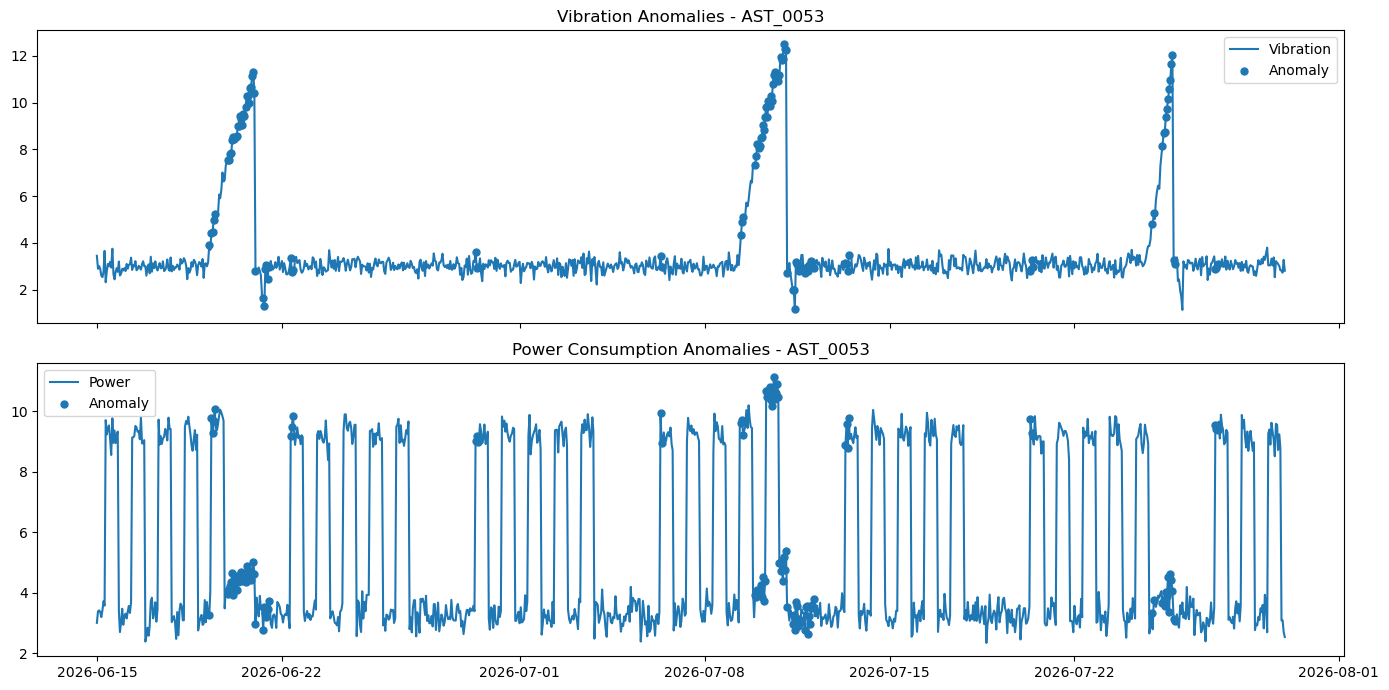

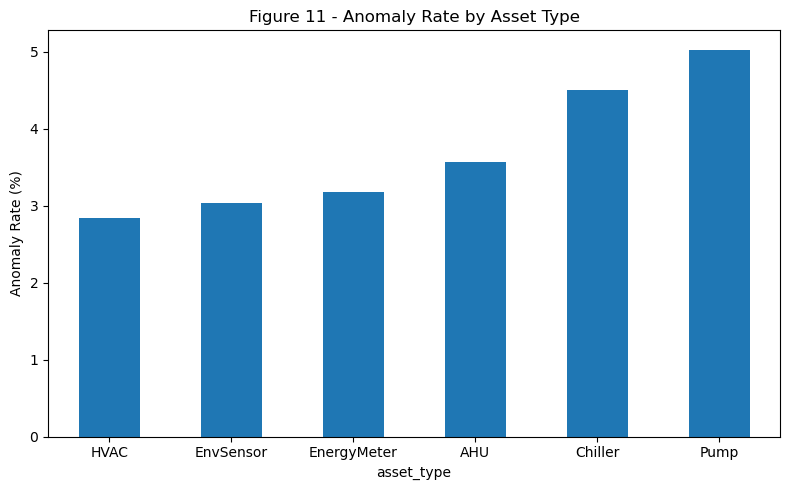

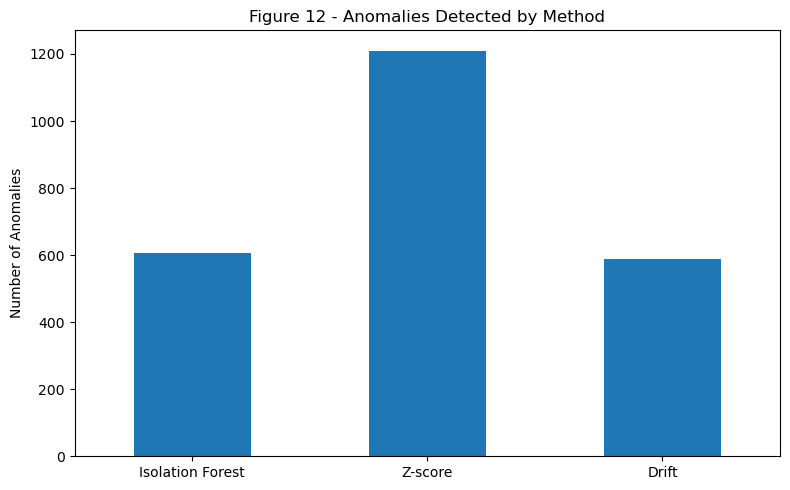

In [16]:
%matplotlib inline
# ============================================================
# 9. SAVE DATA
# ============================================================

telemetry.to_csv(
    DATA / "telemetry_with_anomalies.csv",
    index=False
)


# ============================================================
# 10. SAVE SUMMARY
# ============================================================

summary = {
    "total_observations": int(total),
    "isolation_forest_anomalies": int(iso_count),
    "statistical_anomalies": int(stat_count),
    "drift_anomalies": int(drift_count),
    "total_anomalies": int(total_anomalies),
    "anomaly_rate_percent": round(
        total_anomalies / total * 100,
        2
    ),
    "severity": {
        "critical": int(
            (telemetry["severity"] == "Critical").sum()
        ),
        "high": int(
            (telemetry["severity"] == "High").sum()
        ),
        "warning": int(
            (telemetry["severity"] == "Warning").sum()
        )
    }
}

with open(
    MODELS / "anomaly_detection_summary.json",
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# ============================================================
# 11. FIGURE 1 - ANOMALY EXAMPLE
# ============================================================

# Select asset with most anomalies

example_asset = (
    telemetry
    .groupby("asset_id")["any_anomaly"]
    .sum()
    .idxmax()
)

sample = telemetry[
    telemetry["asset_id"] == example_asset
].sort_values("timestamp")

anomalies = sample[
    sample["any_anomaly"] == 1
]


fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 7),
    sharex=True
)

axes[0].plot(
    sample["timestamp"],
    sample["vibration"],
    label="Vibration"
)

axes[0].scatter(
    anomalies["timestamp"],
    anomalies["vibration"],
    s=25,
    label="Anomaly"
)

axes[0].set_title(
    f"Vibration Anomalies - {example_asset}"
)

axes[0].legend()


axes[1].plot(
    sample["timestamp"],
    sample["power_consumption"],
    label="Power"
)

axes[1].scatter(
    anomalies["timestamp"],
    anomalies["power_consumption"],
    s=25,
    label="Anomaly"
)

axes[1].set_title(
    f"Power Consumption Anomalies - {example_asset}"
)

axes[1].legend()

fig.tight_layout()

fig.savefig(
    FIG / "fig10_anomaly_example.png",
    dpi=130
)
plt.show()
plt.close(fig)


# ============================================================
# 12. FIGURE 2 - ANOMALY BY ASSET TYPE
# ============================================================

by_type = (
    telemetry
    .groupby("asset_type")["any_anomaly"]
    .mean()
    .mul(100)
    .sort_values()
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

by_type.plot(
    kind="bar",
    ax=ax
)

ax.set_ylabel("Anomaly Rate (%)")
ax.set_title(
    "Figure 11 - Anomaly Rate by Asset Type"
)

ax.tick_params(
    axis="x",
    rotation=0
)

fig.tight_layout()

fig.savefig(
    FIG / "fig11_anomaly_by_type.png",
    dpi=130
)
plt.show()
plt.close(fig)


# ============================================================
# 13. FIGURE 3 - METHODS COMPARISON
# ============================================================

method_counts = pd.Series({
    "Isolation Forest": iso_count,
    "Z-score": stat_count,
    "Drift": drift_count
})

fig, ax = plt.subplots(
    figsize=(8, 5)
)

method_counts.plot(
    kind="bar",
    ax=ax
)

ax.set_ylabel(
    "Number of Anomalies"
)

ax.set_title(
    "Figure 12 - Anomalies Detected by Method"
)

ax.tick_params(
    axis="x",
    rotation=0
)

fig.tight_layout()

fig.savefig(
    FIG / "fig12_anomaly_methods.png",
    dpi=130
)
plt.show()

plt.close(fig)

